# Breast Cancer Gene-Expression Analysis

This project analyzes the public **GSE42568** microarray dataset from NCBI GEO. It compares 17 normal breast samples with 104 breast-cancer samples to identify differentially expressed probes and visualize global expression patterns.

**Skills demonstrated:** public-data retrieval, gene-expression analysis, quality control, Welch's t-test, Benjamini-Hochberg multiple-testing correction, PCA, volcano plots, heatmaps, and reproducible Python analysis.

## Important scope

This is an educational analysis of a processed microarray dataset. It is not a clinical diagnostic study. Statistical association does not establish causation, and candidate genes require independent biological validation.

In [37]:
!pip -q install statsmodels seaborn scikit-learn

In [38]:
import gzip
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Download the processed GEO series matrix

GSE42568 was measured on the Affymetrix GPL570 platform. NCBI reports that the sample values are already log2 GC-RMA signal intensities, so the notebook does not apply another log transformation.

In [39]:
matrix_url = 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE42nnn/GSE42568/matrix/GSE42568_series_matrix.txt.gz'
matrix_file = Path('GSE42568_series_matrix.txt.gz')

if not matrix_file.exists():
    urllib.request.urlretrieve(matrix_url, matrix_file)

print(f'Downloaded: {matrix_file.name} ({matrix_file.stat().st_size / 1_000_000:.1f} MB)')

Downloaded: GSE42568_series_matrix.txt.gz (22.6 MB)


## 2. Read sample metadata and the expression matrix

In [40]:
sample_titles = []
sample_accessions = []

with gzip.open(matrix_file, 'rt') as handle:
    for line in handle:
        if line.startswith('!Sample_title'):
            sample_titles = [item.strip().strip('\"') for item in line.rstrip().split('\t')[1:]]
        elif line.startswith('!Sample_geo_accession'):
            sample_accessions = [item.strip().strip('\"') for item in line.rstrip().split('\t')[1:]]
        elif line.startswith('!series_matrix_table_begin'):
            break

expression = pd.read_csv(
    matrix_file, sep='\t', comment='!', compression='gzip', index_col=0
)
expression.index = expression.index.astype(str).str.replace('\"', '', regex=False)
expression.columns = expression.columns.astype(str).str.replace('\"', '', regex=False)
expression = expression.apply(pd.to_numeric, errors='coerce').dropna(how='all')

metadata = pd.DataFrame({'sample': sample_accessions, 'title': sample_titles})
metadata['group'] = np.select(
    [metadata['title'].str.contains('Normal breast', case=False, na=False),
     metadata['title'].str.contains('Breast cancer', case=False, na=False)],
    ['Normal', 'Cancer'],
    default='Unknown'
)
metadata = metadata.set_index('sample').loc[expression.columns].reset_index()

print(f'Expression matrix: {expression.shape[0]:,} probes x {expression.shape[1]} samples')
display(metadata['group'].value_counts().to_frame('sample_count'))
display(metadata.head())

Expression matrix: 54,675 probes x 121 samples


,sample_count
group,
Cancer,104
Normal,17


,index,title,group
0,GSM1045191,"Normal breast, N1_15_12_04",Normal
1,GSM1045192,"Normal breast, N4_14_12_04",Normal
2,GSM1045193,"Normal breast, N5_15_12_04",Normal
3,GSM1045194,"Normal breast, N6_14_12_04",Normal
4,GSM1045195,"Normal breast, P1_15_12_04",Normal


In [41]:
assert set(metadata['group']) == {'Normal', 'Cancer'}, 'Unexpected sample labels detected.'
assert (metadata['group'] == 'Normal').sum() == 17, 'Expected 17 normal samples.'
assert (metadata['group'] == 'Cancer').sum() == 104, 'Expected 104 cancer samples.'
assert expression.shape[1] == 121, 'Expected 121 samples in total.'
print('Sample-label checks passed.')

Sample-label checks passed.


## 3. Quality-control overview

Boxplots allow us to compare the distributions of processed expression values. Similar medians and ranges are expected because the GEO record contains normalized GC-RMA values.

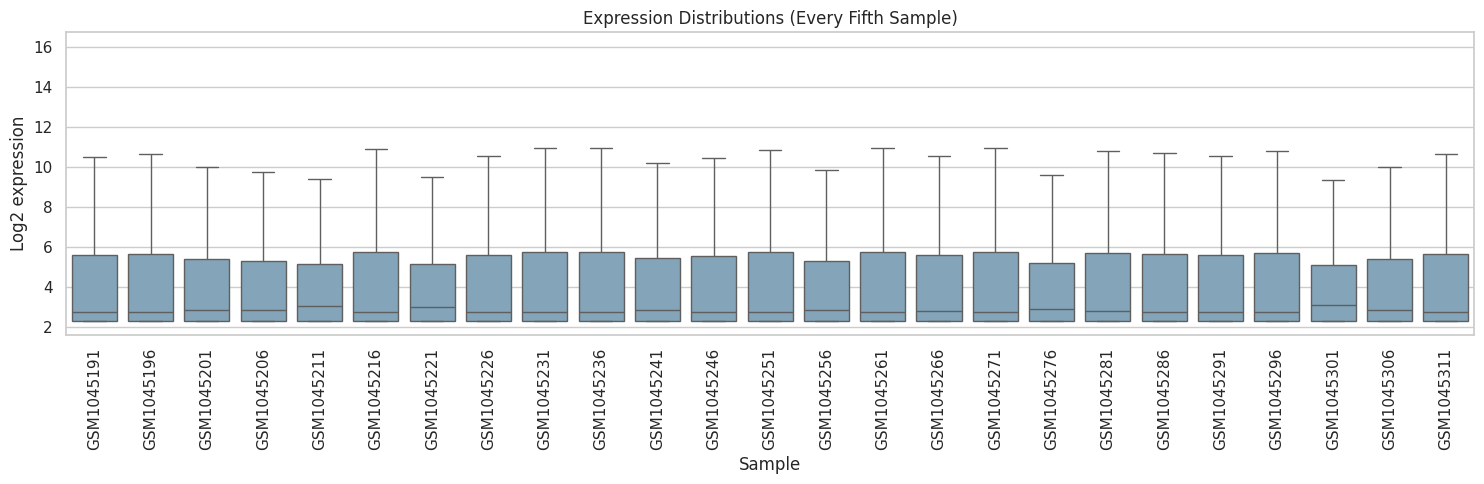

In [42]:
plot_samples = expression.columns[::5]
qc_data = expression[plot_samples].melt(var_name='Sample', value_name='Log2 expression')

plt.figure(figsize=(15, 5))
sns.boxplot(data=qc_data, x='Sample', y='Log2 expression', color='#7AA6C2', fliersize=0)
plt.title('Expression Distributions (Every Fifth Sample)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. Principal component analysis

PCA reduces thousands of probe measurements to a small number of components. It is used here to visualize major expression patterns—not to prove diagnostic separation.

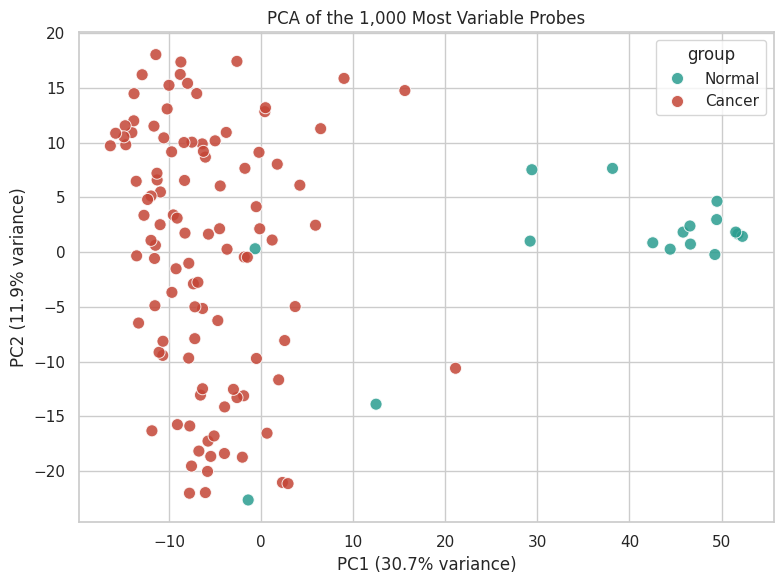

In [43]:
probe_variance = expression.var(axis=1).sort_values(ascending=False)
top_variable_probes = probe_variance.head(1000).index
pca_input = expression.loc[top_variable_probes].T
pca_scaled = StandardScaler().fit_transform(pca_input)
pca = PCA(n_components=2, random_state=42)
coordinates = pca.fit_transform(pca_scaled)

pca_df = metadata.copy()
pca_df['PC1'] = coordinates[:, 0]
pca_df['PC2'] = coordinates[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', palette={'Normal':'#2A9D8F', 'Cancer':'#C44536'}, s=75, alpha=0.85)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of the 1,000 Most Variable Probes')
plt.tight_layout()
plt.show()

In [44]:
metadata = metadata.rename(columns={metadata.columns[0]: 'sample'})

## 5. Differential-expression testing

For every probe, the notebook calculates the difference between mean cancer and mean normal log2 expression. Because the group sizes and variances may differ, it uses **Welch's independent-samples t-test**. Benjamini-Hochberg correction controls the false discovery rate across thousands of simultaneous tests.

In [45]:
normal_samples = metadata.loc[metadata['group'] == 'Normal', 'sample'].tolist()
cancer_samples = metadata.loc[metadata['group'] == 'Cancer', 'sample'].tolist()

normal_values = expression[normal_samples]
cancer_values = expression[cancer_samples]

log2_fc = cancer_values.mean(axis=1) - normal_values.mean(axis=1)
test_result = ttest_ind(cancer_values.values, normal_values.values, axis=1, equal_var=False, nan_policy='omit')
raw_p = np.nan_to_num(test_result.pvalue, nan=1.0)
adjusted_p = multipletests(raw_p, method='fdr_bh')[1]

results = pd.DataFrame({
    'probe_id': expression.index,
    'mean_normal': normal_values.mean(axis=1).values,
    'mean_cancer': cancer_values.mean(axis=1).values,
    'log2_fold_change': log2_fc.values,
    'p_value': raw_p,
    'adjusted_p_value': adjusted_p
})

results['significant'] = (results['adjusted_p_value'] < 0.05) & (results['log2_fold_change'].abs() >= 1)
results['direction'] = np.select(
    [results['significant'] & (results['log2_fold_change'] > 0),
     results['significant'] & (results['log2_fold_change'] < 0)],
    ['Higher in cancer', 'Lower in cancer'],
    default='Not significant'
)
results = results.sort_values(['adjusted_p_value', 'log2_fold_change'], ascending=[True, False])

display(results['direction'].value_counts().to_frame('probe_count'))
display(results.head(10))

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


,probe_count
direction,
Not significant,48219
Higher in cancer,3409
Lower in cancer,3047


,probe_id,mean_normal,mean_cancer,log2_fold_change,p_value,adjusted_p_value,significant,direction
15388,205941_s_at,3.397893,6.990270,3.592377,2.381322e-37,1.301988e-32,True,Higher in cancer
32816,223540_at,3.446957,5.311889,1.864932,3.469596e-30,9.485007e-26,True,Higher in cancer
54536,59697_at,2.661644,4.340283,1.678639,1.012895e-26,1.846002e-22,True,Higher in cancer
36895,227641_at,4.023494,7.077863,3.054369,8.007609e-26,8.756320e-22,True,Higher in cancer
3549,1557289_s_at,3.097402,5.224561,2.127159,6.714834e-26,8.756320e-22,True,Higher in cancer
26713,217428_s_at,3.581115,7.143732,3.562617,1.774348e-25,1.531320e-21,True,Higher in cancer
45711,236462_at,2.592467,4.159958,1.567491,1.960537e-25,1.531320e-21,True,Higher in cancer
13325,203878_s_at,3.537390,6.942168,3.404778,4.797246e-25,3.278618e-21,True,Higher in cancer
44787,235538_at,2.870709,5.410258,2.539549,6.616865e-25,4.019745e-21,True,Higher in cancer
45908,236659_x_at,2.895815,4.275585,1.379771,2.815849e-24,1.539565e-20,True,Higher in cancer


## 6. Volcano plot

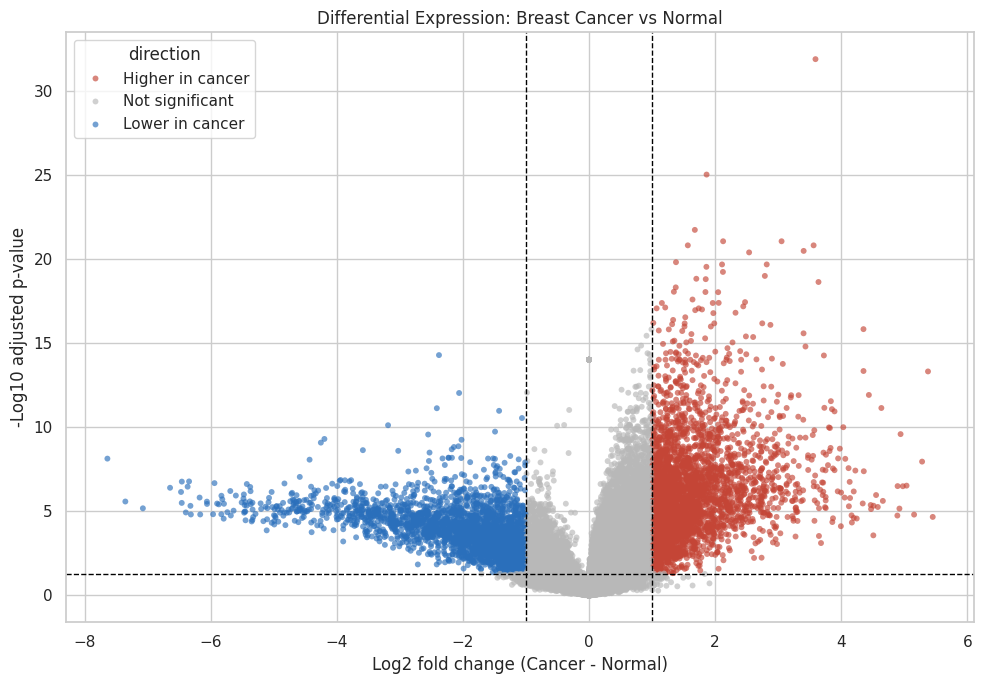

In [46]:
volcano = results.copy()
volcano['minus_log10_adjusted_p'] = -np.log10(volcano['adjusted_p_value'].clip(lower=1e-300))
palette = {'Not significant':'#B8B8B8', 'Higher in cancer':'#C44536', 'Lower in cancer':'#2A6FBB'}

plt.figure(figsize=(10, 7))
sns.scatterplot(data=volcano, x='log2_fold_change', y='minus_log10_adjusted_p', hue='direction', palette=palette, s=18, alpha=0.65, linewidth=0)
plt.axvline(1, color='black', linestyle='--', linewidth=1)
plt.axvline(-1, color='black', linestyle='--', linewidth=1)
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)
plt.xlabel('Log2 fold change (Cancer - Normal)')
plt.ylabel('-Log10 adjusted p-value')
plt.title('Differential Expression: Breast Cancer vs Normal')
plt.tight_layout()
plt.show()

## 7. Heatmap of leading differentially expressed probes

The heatmap uses row-wise z-scores, so each probe is displayed relative to its own mean and standard deviation. These colors do not represent absolute expression levels.

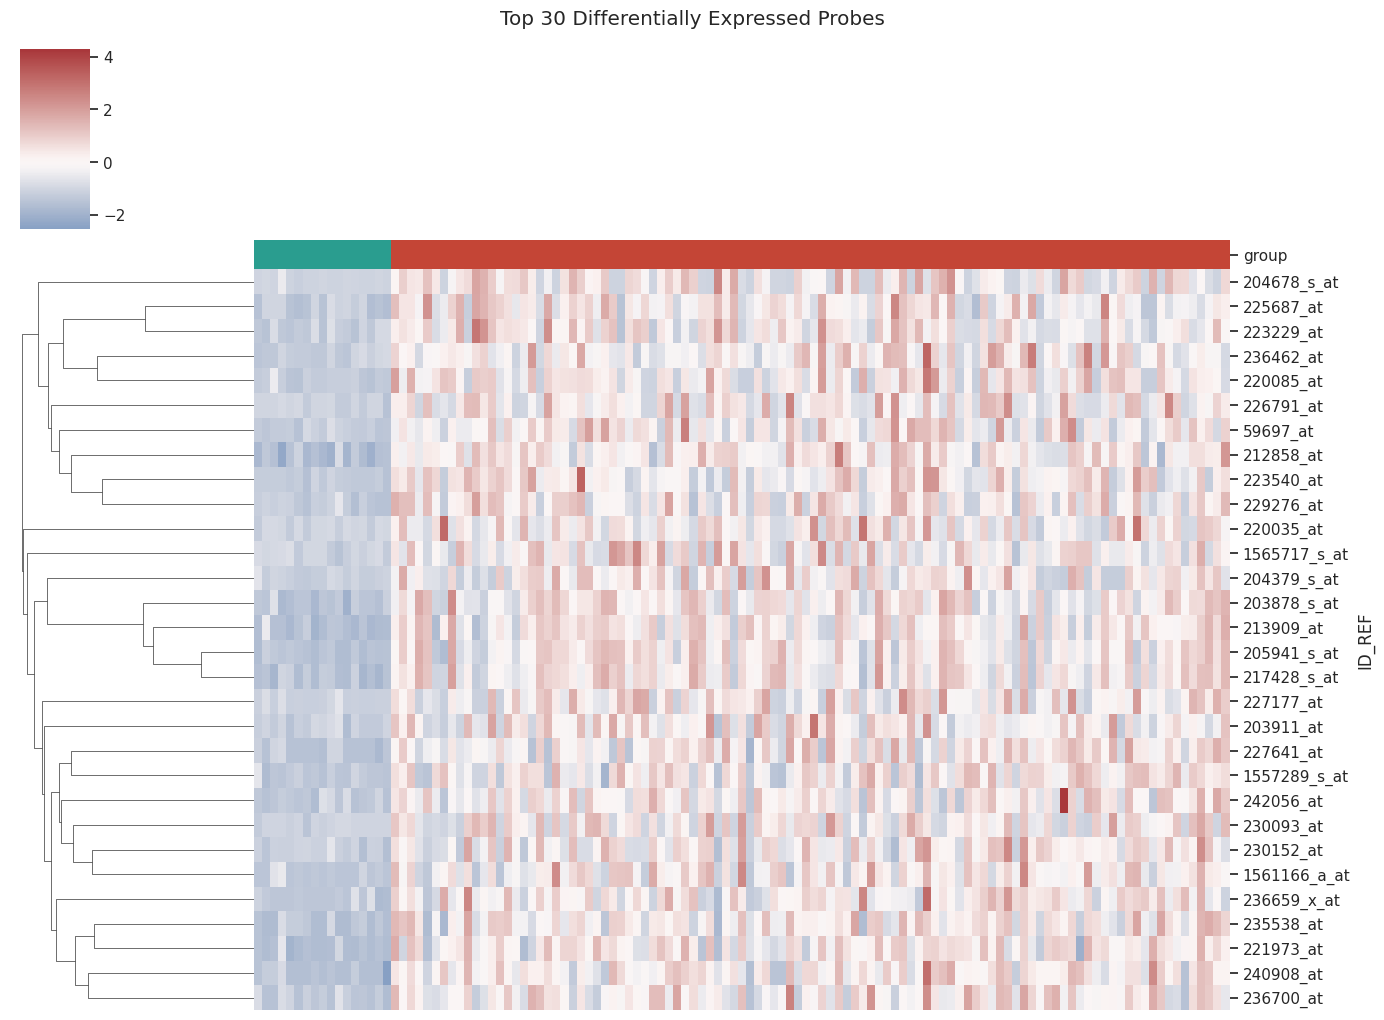

In [47]:
leading = results.loc[results['significant']].head(30)['probe_id']
heatmap_values = expression.loc[leading]
heatmap_z = heatmap_values.sub(heatmap_values.mean(axis=1), axis=0).div(heatmap_values.std(axis=1).replace(0, np.nan), axis=0)
ordered_samples = normal_samples + cancer_samples
column_colors = pd.Series(metadata.set_index('sample')['group']).map({'Normal':'#2A9D8F', 'Cancer':'#C44536'}).loc[ordered_samples]

sns.clustermap(
    heatmap_z[ordered_samples], cmap='vlag', center=0, col_cluster=False,
    col_colors=column_colors, xticklabels=False, yticklabels=True, figsize=(14, 10)
)
plt.suptitle('Top 30 Differentially Expressed Probes', y=1.02)
plt.show()

## 8. Optional probe-to-gene annotation

The following cell downloads the official GPL570 annotation table and attaches available gene symbols. Some probes map to multiple genes or lack a current symbol; those ambiguities are preserved rather than silently discarded.

In [48]:
!pip -q install GEOparse

import GEOparse

# Download the official Affymetrix GPL570 platform annotation
gpl = GEOparse.get_GEO(
    geo="GPL570",
    destdir="."
)

annotation = gpl.table.copy()

# Find the gene-symbol column safely
symbol_column = next(
    (
        column for column in annotation.columns
        if column.lower().replace(" ", "_")
        in {"gene_symbol", "gene_symbols"}
    ),
    None
)

if symbol_column is None:
    raise KeyError(
        f"Gene-symbol column not found. Available columns: "
        f"{annotation.columns.tolist()}"
    )

probe_symbols = annotation[
    ["ID", symbol_column]
].copy()

probe_symbols = probe_symbols.rename(
    columns={
        "ID": "probe_id",
        symbol_column: "gene_symbol"
    }
)

probe_symbols["probe_id"] = probe_symbols["probe_id"].astype(str)

annotated_results = results.merge(
    probe_symbols,
    on="probe_id",
    how="left"
)

columns_to_show = [
    "probe_id",
    "gene_symbol",
    "log2_fold_change",
    "adjusted_p_value",
    "direction"
]

display(
    annotated_results.loc[
        annotated_results["significant"],
        columns_to_show
    ].head(20)
)

17-Aug-2026 08:24:21 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
17-Aug-2026 08:24:21 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
17-Aug-2026 08:24:21 INFO GEOparse - Parsing ./GPL570.txt: 
INFO:GEOparse:Parsing ./GPL570.txt: 
17-Aug-2026 08:24:21 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


,probe_id,gene_symbol,log2_fold_change,adjusted_p_value,direction
0,205941_s_at,COL10A1,3.592377,1.301988e-32,Higher in cancer
1,223540_at,PVRL4,1.864932,9.485007e-26,Higher in cancer
2,59697_at,RAB15,1.678639,1.846002e-22,Higher in cancer
3,227641_at,FBXL16,3.054369,8.756320e-22,Higher in cancer
4,1557289_s_at,GTF2IRD2,2.127159,8.756320e-22,Higher in cancer
5,217428_s_at,COL10A1,3.562617,1.531320e-21,Higher in cancer
6,236462_at,NaN,1.567491,1.531320e-21,Higher in cancer
7,203878_s_at,MMP11,3.404778,3.278618e-21,Higher in cancer
8,235538_at,NaN,2.539549,4.019745e-21,Higher in cancer
9,236659_x_at,NaN,1.379771,1.539565e-20,Higher in cancer


## 9. Export reproducible results

The full statistical table is exported. The processed GEO matrix itself is not re-uploaded to GitHub because the notebook retrieves it from its original public source.

In [49]:
annotated_results.to_csv('GSE42568_differential_expression_results.csv', index=False)
metadata.to_csv('GSE42568_sample_metadata.csv', index=False)

project_summary = pd.DataFrame({
    'metric': ['Dataset', 'Normal samples', 'Cancer samples', 'Tested probes', 'Significant probes'],
    'value': ['GSE42568', len(normal_samples), len(cancer_samples), len(results), int(results['significant'].sum())]
})
project_summary.to_csv('GSE42568_project_summary.csv', index=False)
display(project_summary)
print('Results exported successfully.')

,metric,value
0,Dataset,GSE42568
1,Normal samples,17
2,Cancer samples,104
3,Tested probes,54675
4,Significant probes,6456


Results exported successfully.


## Interpretation and limitations

- PCA summarizes major variation but does not prove that a model will generalize to new patients.
- The unequal group sizes (17 normal versus 104 cancer) motivated use of Welch's t-test, which does not assume equal variances.
- Benjamini-Hochberg correction reduces false discoveries caused by testing tens of thousands of probes.
- A threshold of adjusted p-value < 0.05 and absolute log2 fold change >= 1 was chosen for this educational analysis; thresholds should be justified for each research question.
- Microarray probes are not identical to genes. Multiple probes can map to one gene, and some mappings are ambiguous or outdated.
- Important confounders, tumor subtypes, batch effects, clinical characteristics, and independent validation are outside this introductory notebook.
- Findings are hypothesis-generating and must not be presented as clinical biomarkers without further validation.